In [ ]:
from google.colab import drive
import os
import pandas as pd

In [ ]:
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/個人加分作業')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_used = pd.read_csv('/content/drive/MyDrive/個人加分作業/AI.csv')

# k-means clustering

In [ ]:
df_used = df_used[['road_DIST', 'earthquake_reactor', 'lightning', 'Population_a_', 'volcano_DIST']]
df_used.head(5)

,road_DIST,earthquake_reactor,lightning,Population_a_,volcano_DIST
0,0.021964,17.684889,499,24017,1.818461
1,0.021091,20.369406,231,39132,0.765437
2,0.011138,32.344559,282,30650,3.311149
3,0.056464,130.257584,167,12006,0.387912
4,0.003221,54.562843,566,21840,0.108582


## Select k

In [ ]:
num_clusters = 7
sse = []
for k in range(1, num_clusters):
    kmeans = KMeans(n_clusters = k, init = 'k-means++', max_iter = 50, random_state = 0)
    kmeans.fit(df_used)
    sse.append(kmeans.inertia_)

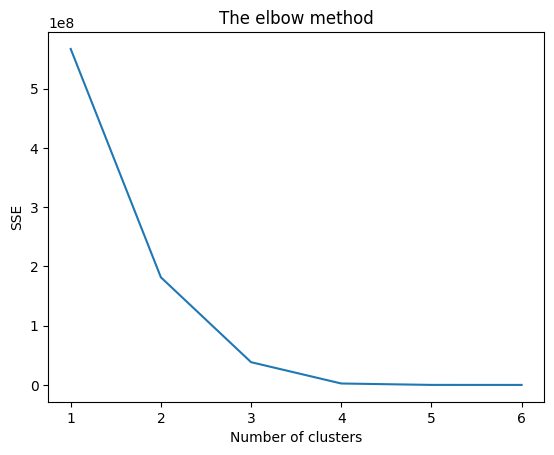

In [ ]:
# 用Elbow Method 找出最適分群數量

plt.plot(range(1, num_clusters), sse)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

In [ ]:
num_clusters= 4 # Elbow 顯示轉折點位置

In [ ]:
for k in range(1, num_clusters):#再跑一次
    kmeans = KMeans(n_clusters = k, init = 'k-means++', max_iter = 50, random_state = 0)
    kmeans.fit(df_used)
    sse.append(kmeans.inertia_)

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_used)


# 設定你選的最佳 K 值

kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=50, random_state=0)
kmeans.fit(df_scaled)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)

centroid_df = pd.DataFrame(centroids, columns=['road_DIST', 'earthquake_reactor', 'lightning', 'Population_a_', 'volcano_DIST'])

centroid_sorted = centroid_df.sort_values(by='earthquake_reactor', ascending=False)
print("各群中心點（依照 earthquake_reactor 值排序）：")
print(centroid_sorted)

各群中心點（依照 earthquake_reactor 值排序）：
   road_DIST  earthquake_reactor   lightning  Population_a_  volcano_DIST
0   0.056464          130.257584  167.000000   12006.000000      0.387912
1   0.011133           40.070622  458.333333   19224.333333      0.683435
2   0.016115           26.356982  256.500000   34891.000000      2.038293


In [ ]:
df_used['cluster'] = kmeans.labels_

In [ ]:
df_used.head(6)

,road_DIST,earthquake_reactor,lightning,Population_a_,volcano_DIST,cluster
0,0.021964,17.684889,499,24017,1.818461,1
1,0.021091,20.369406,231,39132,0.765437,2
2,0.011138,32.344559,282,30650,3.311149,2
3,0.056464,130.257584,167,12006,0.387912,0
4,0.003221,54.562843,566,21840,0.108582,1
5,0.008212,47.964134,310,11816,0.123263,1
